In [4]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Resolve event file path from project root
project_root = Path.cwd().parent
candidate_paths = [
    project_root / 'data' / 'external' / 'events.csv',
    project_root / 'data' / 'external' / '.ipynb_checkpoints' / 'events.csv',
]

csv_path = next((path for path in candidate_paths if path.exists()), None)
if csv_path is None:
    available_external = [p.name for p in (project_root / 'data' / 'external').glob('*')]
    available_checkpoint = [p.name for p in (project_root / 'data' / 'external' / '.ipynb_checkpoints').glob('*')]
    raise FileNotFoundError(
        'Could not find events.csv in expected locations.\n'
        f'Tried: {[str(p) for p in candidate_paths]}\n'
        f'data/external contents: {available_external}\n'
        f'data/external/.ipynb_checkpoints contents: {available_checkpoint}'
    )

# Load your event dataset
events_df = pd.read_csv(csv_path)

print('Event Data Overview:')
print(f'Total events: {len(events_df):,}')
print(f'\nLoaded from: {csv_path}')
print(f'\nColumns: {events_df.columns.tolist()}')
print(f'\nFirst few records:')
print(events_df.head(10))

print(f'\nData types:')
print(events_df.dtypes)

print(f'\nMissing values:')
print(events_df.isnull().sum())

Event Data Overview:
Total events: 519

Loaded from: d:\DOING STUFF\GRID\grid_ml\data\external\.ipynb_checkpoints\events.csv

Columns: ['event_id', 'event_date', 'borough', 'event_category', 'event_subtype', 'estimated_attendance', 'event_intensity_score', 'is_weekend']

First few records:
   event_id  event_date    borough         event_category  \
0         1  2025-01-01  Manhattan  Music & Entertainment   
1         2  2025-01-01     Queens  Music & Entertainment   
2         3  2025-01-02  Manhattan  Music & Entertainment   
3         4  2025-01-02     Queens  Music & Entertainment   
4         5  2025-01-02   Brooklyn                 Sports   
5         6  2025-01-02  Manhattan   Business & Corporate   
6         7  2025-01-03  Manhattan  Music & Entertainment   
7         8  2025-01-03     Queens  Music & Entertainment   
8         9  2025-01-04  Manhattan  Music & Entertainment   
9        10  2025-01-04     Queens  Music & Entertainment   

          event_subtype  estimated_at

## Step 2: Event Data Preprocessing
Standardise dates, normalise categories, and remove duplicates.

In [5]:
def preprocess_event_data(events_df):
    """
    Preprocess event data for integration with demand model.
    Adapted to actual schema: event_date, borough, event_category,
    event_subtype, estimated_attendance, event_intensity_score.
    """
    df = events_df.copy()

    # Parse event_date
    df['event_date'] = pd.to_datetime(df['event_date']).dt.normalize()

    # Normalise text fields
    df['event_category'] = df['event_category'].str.strip()
    df['event_subtype']  = df['event_subtype'].str.strip()
    df['borough']        = df['borough'].str.strip()

    # Fill missing attendance with median
    median_att = df['estimated_attendance'].median()
    df['estimated_attendance'] = df['estimated_attendance'].fillna(median_att)

    # Drop exact duplicates
    before = len(df)
    df = df.drop_duplicates(subset=['event_date', 'borough', 'event_subtype'], keep='first')
    print(f"Dropped {before - len(df)} duplicate rows, {len(df):,} events remain")
    print(f"Date range : {df['event_date'].min().date()} → {df['event_date'].max().date()}")
    print(f"\nEvent categories:\n{df['event_category'].value_counts()}")
    print(f"\nBoroughs:\n{df['borough'].value_counts()}")
    print(f"\nTop subtypes:\n{df['event_subtype'].value_counts().head(10)}")
    return df

events_clean = preprocess_event_data(events_df)


Dropped 0 duplicate rows, 519 events remain
Date range : 2025-01-01 → 2025-06-30

Event categories:
event_category
Music & Entertainment    362
Sports                    85
Public & Cultural         49
Business & Corporate      23
Name: count, dtype: int64

Boroughs:
borough
Queens       228
Manhattan    213
Brooklyn      64
Bronx         14
Name: count, dtype: int64

Top subtypes:
event_subtype
Broadway Show           181
Cultural Music Night    181
NBA Game                 51
Street Fair              30
MLB Game                 26
Food Festival            18
Tech Conference          16
NFL Special Event         8
Startup Meetup            7
Pride Parade              1
Name: count, dtype: int64


## Step 3: Map Events to Taxi Zones (Borough-Level)
Events carry only a borough name. We expand each event to touch every LocationID in that borough so we can join on `PULocationID`.

In [6]:
# Standard NYC TLC borough → LocationID mapping
# Source: NYC TLC Taxi Zone lookup (taxi_zones.csv)
BOROUGH_TO_ZONES = {
    'Manhattan': [
        4,12,13,24,41,42,43,45,48,50,68,74,75,79,87,88,90,
        100,103,104,105,107,113,114,116,120,125,127,128,137,
        140,141,142,143,144,148,151,152,153,158,161,162,163,
        164,166,170,186,194,202,209,211,224,229,230,231,232,
        233,234,236,237,238,239,243,244,246,249,261,262,263
    ],
    'Brooklyn': [
        11,14,17,21,22,25,26,29,33,34,36,37,39,40,49,52,54,
        55,61,62,63,65,66,67,71,72,76,77,80,85,89,91,97,106,
        108,112,123,133,149,150,154,155,165,177,178,181,188,
        189,190,195,210,217,222,225,227,228,255,256,257,258
    ],
    'Queens': [
        2,7,8,9,10,15,16,19,27,28,30,38,53,56,57,64,70,73,
        82,83,86,92,93,95,96,98,101,102,117,121,122,124,129,
        130,131,132,134,135,138,139,145,146,157,160,171,173,
        175,179,180,191,192,193,196,197,198,201,203,205,207,
        215,216,218,219,223,226,252,253,259
    ],
    'Bronx': [
        3,6,18,20,31,32,46,47,51,58,59,60,69,78,81,94,119,
        126,136,147,159,167,168,169,174,182,183,184,185,199,
        200,208,212,213,220,235,240,241,242,247,248,250,254
    ],
    'Staten Island': [
        5,23,44,84,99,109,110,115,118,156,172,176,187,204,
        206,214,221,245,251
    ],
}

# Build reverse lookup: LocationID → borough
ZONE_TO_BOROUGH = {
    zone: borough
    for borough, zones in BOROUGH_TO_ZONES.items()
    for zone in zones
}

def expand_events_to_zones(events_clean, borough_to_zones):
    """
    Replicate each event row for every LocationID in its borough,
    producing a zone-level events table ready for merging.
    """
    rows = []
    for _, ev in events_clean.iterrows():
        zones = borough_to_zones.get(ev['borough'], [])
        for z in zones:
            rows.append({
                'event_date':           ev['event_date'],
                'PULocationID':         z,
                'borough':              ev['borough'],
                'event_category':       ev['event_category'],
                'event_subtype':        ev['event_subtype'],
                'estimated_attendance': ev['estimated_attendance'],
                'event_intensity_score':ev['event_intensity_score'],
            })
    events_zoned = pd.DataFrame(rows)
    print(f"Zone-level event rows: {len(events_zoned):,}")
    print(f"Unique (date, zone) pairs: {events_zoned[['event_date','PULocationID']].drop_duplicates().shape[0]:,}")
    return events_zoned

events_zoned = expand_events_to_zones(events_clean, BOROUGH_TO_ZONES)
events_zoned.head()


Zone-level event rows: 34,643
Unique (date, zone) pairs: 29,059


,event_date,PULocationID,borough,event_category,event_subtype,estimated_attendance,event_intensity_score
0,2025-01-01,4,Manhattan,Music & Entertainment,Broadway Show,973,1
1,2025-01-01,12,Manhattan,Music & Entertainment,Broadway Show,973,1
2,2025-01-01,13,Manhattan,Music & Entertainment,Broadway Show,973,1
3,2025-01-01,24,Manhattan,Music & Entertainment,Broadway Show,973,1
4,2025-01-01,41,Manhattan,Music & Entertainment,Broadway Show,973,1


## Step 4 & 5: Engineer Event Features (Optimised Vectorised Merge)
We aggregate zone-level event attributes into a single set of per-(date, zone) features, then left-join onto the full demand table.

In [7]:
def create_event_features_optimized(demand_df, events_zoned):
    """
    Vectorised event feature creation.
    Merges zone-level events onto demand on (date, PULocationID),
    then aggregates per zone-day into clean feature columns.
    """
    df = demand_df.copy()
    df['date'] = pd.to_datetime(df['date'])

    # ── aggregate events to one row per (event_date, PULocationID) ────────
    ev = events_zoned.copy()
    ev['is_music_entertainment'] = (ev['event_category'] == 'Music & Entertainment').astype(int)
    ev['is_sports']    = (ev['event_category'] == 'Sports').astype(int)
    ev['is_conference']= (ev['event_category'] == 'Business & Corporate').astype(int)
    ev['is_cultural']  = (ev['event_category'] == 'Public & Cultural').astype(int)
    ev['is_nba']       = (ev['event_subtype'] == 'NBA Game').astype(int)
    ev['is_mlb']       = (ev['event_subtype'] == 'MLB Game').astype(int)
    ev['is_nfl']       = (ev['event_subtype'] == 'NFL Special Event').astype(int)
    ev['is_broadway']  = (ev['event_subtype'] == 'Broadway Show').astype(int)
    ev['is_food_fest'] = (ev['event_subtype'] == 'Food Festival').astype(int)
    ev['is_pride']     = (ev['event_subtype'] == 'Pride Parade').astype(int)

    agg = ev.groupby(['event_date', 'PULocationID']).agg(
        event_count              = ('event_intensity_score', 'count'),
        event_attendance_total   = ('estimated_attendance',  'sum'),
        event_intensity_max      = ('event_intensity_score', 'max'),
        is_music_entertainment   = ('is_music_entertainment','max'),
        is_sports                = ('is_sports',             'max'),
        is_conference            = ('is_conference',         'max'),
        is_cultural              = ('is_cultural',           'max'),
        is_nba                   = ('is_nba',                'max'),
        is_mlb                   = ('is_mlb',                'max'),
        is_nfl                   = ('is_nfl',                'max'),
        is_broadway              = ('is_broadway',           'max'),
        is_food_fest             = ('is_food_fest',          'max'),
        is_pride                 = ('is_pride',              'max'),
    ).reset_index().rename(columns={'event_date': 'date'})

    # ── left-join onto demand data ─────────────────────────────────────────
    df = df.merge(agg, on=['date', 'PULocationID'], how='left')

    # fill no-event records with 0
    event_cols = [c for c in agg.columns if c not in ('date', 'PULocationID')]
    df[event_cols] = df[event_cols].fillna(0)
    df['has_event'] = (df['event_count'] > 0).astype(int)

    # ── report ─────────────────────────────────────────────────────────────
    print("Event feature engineering complete")
    print(f"  Total rows         : {len(df):,}")
    print(f"  Rows WITH events   : {df['has_event'].sum():,}  ({df['has_event'].mean()*100:.2f}%)")
    print(f"  Avg attendance     : {df.loc[df['has_event']==1,'event_attendance_total'].mean():,.0f}")
    print(f"\nNew event columns: {[c for c in df.columns if c not in demand_df.columns]}")
    return df

# ── Load existing feature data ─────────────────────────────────────────────
print("Loading existing features …")
existing_features = pd.read_parquet('../data/processed/features_for_ml_full.parquet')
existing_features['date'] = pd.to_datetime(existing_features['date'])
print(f"Existing features shape: {existing_features.shape}")

# ── Create event features ──────────────────────────────────────────────────
features_with_events = create_event_features_optimized(existing_features, events_zoned)
features_with_events.shape


Loading existing features …
Existing features shape: (474283, 20)
Event feature engineering complete
  Total rows         : 474,283
  Rows WITH events   : 37,310  (7.87%)
  Avg attendance     : 5,885

New event columns: ['event_count', 'event_attendance_total', 'event_intensity_max', 'is_music_entertainment', 'is_sports', 'is_conference', 'is_cultural', 'is_nba', 'is_mlb', 'is_nfl', 'is_broadway', 'is_food_fest', 'is_pride', 'has_event']


(474283, 34)

## Step 6: Retrain XGBoost with Event Features

In [8]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Feature columns ────────────────────────────────────────────────────────
BASE_FEATURES = [
    'hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend',
    'is_morning_rush', 'is_evening_rush', 'is_night', 'is_business_hours',
    'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h',
    'demand_rolling_mean_3h', 'demand_rolling_max_6h', 'demand_rolling_std_6h',
    'avg_distance', 'avg_fare',
]

EVENT_FEATURES = [
    'has_event', 'event_count', 'event_attendance_total', 'event_intensity_max',
    'is_music_entertainment', 'is_sports', 'is_conference', 'is_cultural',
    'is_nba', 'is_mlb', 'is_nfl', 'is_broadway', 'is_food_fest', 'is_pride',
]

feature_cols = BASE_FEATURES + EVENT_FEATURES

# ── Chronological 80/20 split ──────────────────────────────────────────────
data = features_with_events.sort_values(['date', 'hour']).reset_index(drop=True).dropna(subset=feature_cols + ['demand'])
split_idx = int(len(data) * 0.8)

train_df = data.iloc[:split_idx]
test_df  = data.iloc[split_idx:]

X_train = train_df[feature_cols]
y_train = train_df['demand']
X_test  = test_df[feature_cols]
y_test  = test_df['demand']

print(f"Train : {len(X_train):,} rows  ({train_df['date'].min().date()} → {train_df['date'].max().date()})")
print(f"Test  : {len(X_test):,} rows   ({test_df['date'].min().date()} → {test_df['date'].max().date()})")
print(f"Features: {len(feature_cols)}  (base={len(BASE_FEATURES)}, event={len(EVENT_FEATURES)})")

# ── Train ──────────────────────────────────────────────────────────────────
model_with_events = xgb.XGBRegressor(
    objective        = 'reg:squarederror',
    max_depth        = 8,
    learning_rate    = 0.05,
    n_estimators     = 300,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 3,
    gamma            = 0.1,
    random_state     = 42,
    n_jobs           = -1,
)

print("\nTraining model with event features …")
model_with_events.fit(
    X_train, y_train,
    eval_set   = [(X_train, y_train), (X_test, y_test)],
    verbose    = 50,
)
print("Training complete.")


Train : 379,426 rows  (2025-06-07 → 2025-10-30)
Test  : 94,857 rows   (2025-10-30 → 2025-11-30)
Features: 31  (base=17, event=14)

Training model with event features …


c:\Users\vidhy\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\data.py:335: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
c:\Users\vidhy\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\data.py:338: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  is_categorical_dtype(dtype) or is_pa_ext_categorical_dtype(dtype)
c:\Users\vidhy\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\data.py:384: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(dtype):
c:\Users\vidhy\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\data.py:359: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version.

[0]	validation_0-rmse:63.71503	validation_1-rmse:66.14525


c:\Users\vidhy\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\data.py:335: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
c:\Users\vidhy\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\data.py:338: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  is_categorical_dtype(dtype) or is_pa_ext_categorical_dtype(dtype)
c:\Users\vidhy\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\data.py:384: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(dtype):
c:\Users\vidhy\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\data.py:359: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version.

[50]	validation_0-rmse:13.48387	validation_1-rmse:15.11458
[100]	validation_0-rmse:11.35628	validation_1-rmse:13.78144
[150]	validation_0-rmse:10.70185	validation_1-rmse:13.62714
[200]	validation_0-rmse:10.27807	validation_1-rmse:13.57430
[250]	validation_0-rmse:9.92484	validation_1-rmse:13.54633
[299]	validation_0-rmse:9.63645	validation_1-rmse:13.54214
Training complete.


## Step 7: Evaluate Event Feature Impact & Feature Importance

c:\Users\vidhy\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\data.py:335: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
c:\Users\vidhy\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\data.py:338: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  is_categorical_dtype(dtype) or is_pa_ext_categorical_dtype(dtype)
c:\Users\vidhy\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\data.py:384: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(dtype):
c:\Users\vidhy\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\data.py:359: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version.

  MODEL PERFORMANCE WITH EVENT FEATURES
  Train R²   : 0.9792    Train RMSE : 9.64
  Test  R²   : 0.9619    Test  RMSE : 13.54
  Test  MAE  : 5.66
  Overfitting (train–test RMSE): -3.91

  COMPARISON WITH PREVIOUS MODEL (no events)
  Metric           Before      After          Δ
  ------------------------------------------
  R²               0.9617     0.9619    +0.0002
  RMSE              13.58      13.54      +0.04
  MAE                6.42       5.66      +0.76

TOP 20 FEATURES (event features marked with *)
    demand_lag_1h                       0.6867
    demand_lag_24h                      0.1122
    is_night                            0.0501
    demand_lag_168h                     0.0491
    demand_rolling_mean_3h              0.0233
    is_morning_rush                     0.0126
    is_business_hours                   0.0100
    hour                                0.0079
    demand_rolling_std_6h               0.0049
    is_weekend                          0.0046
    demand_ro

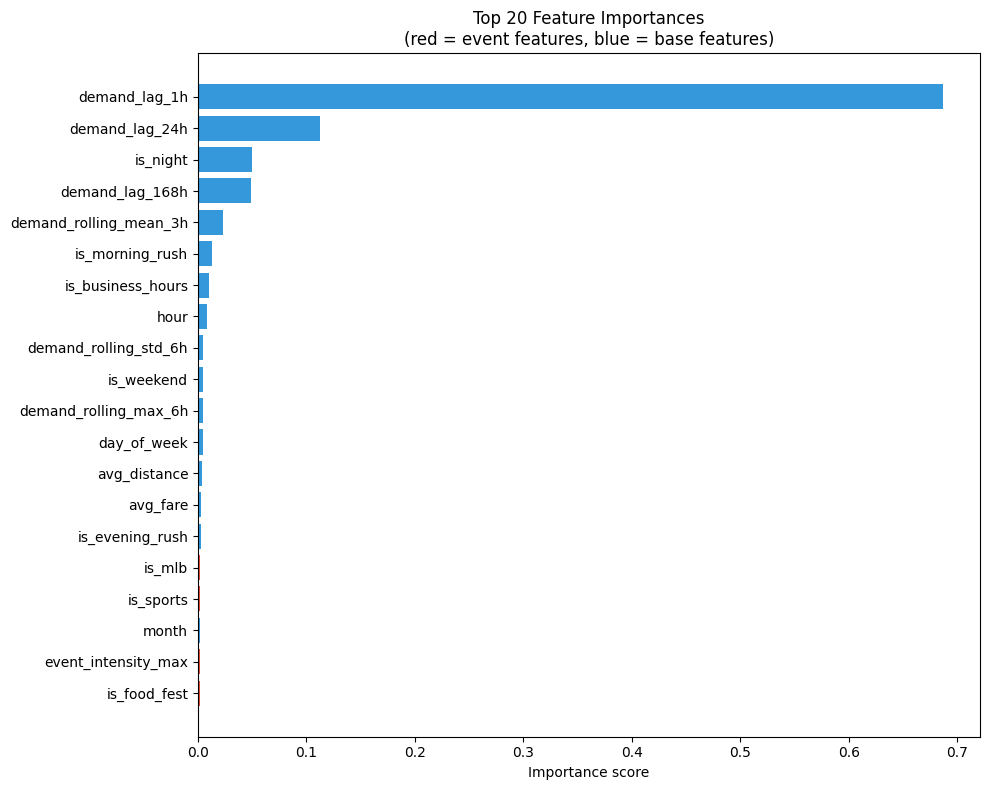

In [9]:
PREV_R2   = 0.9617
PREV_RMSE = 13.58
PREV_MAE  = 6.42   # from prior notebook metadata

y_train_pred = model_with_events.predict(X_train)
y_test_pred  = model_with_events.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test,  y_test_pred))
test_r2    = r2_score(y_test,  y_test_pred)
test_mae   = mean_absolute_error(y_test,  y_test_pred)
train_r2   = r2_score(y_train, y_train_pred)

print("=" * 60)
print("  MODEL PERFORMANCE WITH EVENT FEATURES")
print("=" * 60)
print(f"  Train R²   : {train_r2:.4f}    Train RMSE : {train_rmse:.2f}")
print(f"  Test  R²   : {test_r2:.4f}    Test  RMSE : {test_rmse:.2f}")
print(f"  Test  MAE  : {test_mae:.2f}")
overfit = train_rmse - test_rmse
print(f"  Overfitting (train–test RMSE): {overfit:.2f}")
print()
print("  COMPARISON WITH PREVIOUS MODEL (no events)")
print(f"  {'Metric':<12} {'Before':>10} {'After':>10} {'Δ':>10}")
print(f"  {'-'*42}")
print(f"  {'R²':<12} {PREV_R2:>10.4f} {test_r2:>10.4f} {test_r2 - PREV_R2:>+10.4f}")
print(f"  {'RMSE':<12} {PREV_RMSE:>10.2f} {test_rmse:>10.2f} {PREV_RMSE - test_rmse:>+10.2f}")
print(f"  {'MAE':<12} {PREV_MAE:>10.2f} {test_mae:>10.2f} {PREV_MAE - test_mae:>+10.2f}")
print("=" * 60)

# ── Feature importance ────────────────────────────────────────────────────
importance_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': model_with_events.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("\nTOP 20 FEATURES (event features marked with *)")
for _, row in importance_df.head(20).iterrows():
    tag = " *" if row['feature'] in EVENT_FEATURES else "  "
    print(f"  {tag}{row['feature']:<35s} {row['importance']:.4f}")

event_imp = importance_df[importance_df['feature'].isin(EVENT_FEATURES)]
total_event_imp = event_imp['importance'].sum()
print(f"\nTotal event feature importance: {total_event_imp:.4f}  ({total_event_imp*100:.2f}%)")

# ── Bar chart ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
top20 = importance_df.head(20)
colors = ['#e74c3c' if f in EVENT_FEATURES else '#3498db' for f in top20['feature']]
ax.barh(top20['feature'][::-1], top20['importance'][::-1], color=colors[::-1])
ax.set_xlabel('Importance score')
ax.set_title('Top 20 Feature Importances\n(red = event features, blue = base features)')
plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance_with_events.png', dpi=150)
plt.show()


## Step 8: Event-Day vs Non-Event-Day Performance Analysis

PERFORMANCE BREAKDOWN
                          n     R2    RMSE    MAE
label                                            
All test data         94857 0.9619 13.5421 5.6581
Non-event zones/days  94857 0.9619 13.5421 5.6581


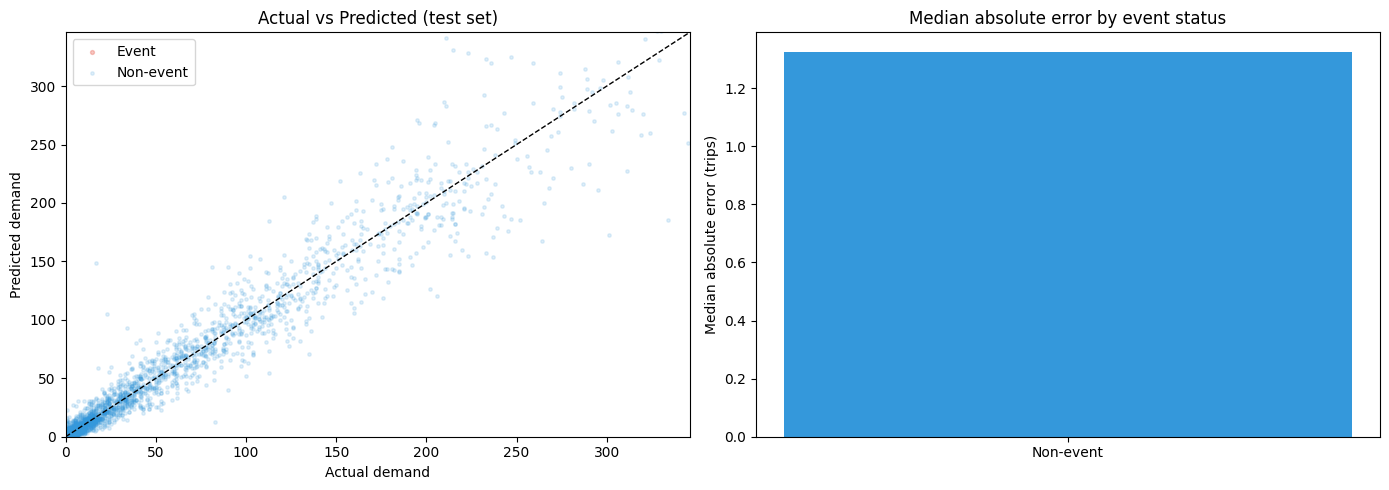

In [10]:
results = test_df.copy()
results['predicted'] = y_test_pred
results['actual']    = y_test.values
results['abs_error'] = np.abs(results['actual'] - results['predicted'])

def metrics_report(label, subset):
    rmse = np.sqrt(mean_squared_error(subset['actual'], subset['predicted']))
    mae  = mean_absolute_error(subset['actual'], subset['predicted'])
    r2   = r2_score(subset['actual'], subset['predicted'])
    return {'label': label, 'n': len(subset), 'R2': r2, 'RMSE': rmse, 'MAE': mae}

event_rows     = results[results['has_event'] == 1]
non_event_rows = results[results['has_event'] == 0]

rows = []
rows.append(metrics_report("All test data",   results))
if len(event_rows) > 1:
    rows.append(metrics_report("Event zones/days",     event_rows))
if len(non_event_rows) > 1:
    rows.append(metrics_report("Non-event zones/days", non_event_rows))

# by event subtype
for subtype in ['NBA Game', 'MLB Game', 'NFL Special Event', 'Broadway Show',
                'Food Festival', 'Pride Parade', 'Tech Conference']:
    col = {
        'NBA Game':         'is_nba',
        'MLB Game':         'is_mlb',
        'NFL Special Event':'is_nfl',
        'Broadway Show':    'is_broadway',
        'Food Festival':    'is_food_fest',
        'Pride Parade':     'is_pride',
        'Tech Conference':  'is_conference',
    }[subtype]
    sub = results[results[col] == 1]
    if len(sub) > 1:
        rows.append(metrics_report(subtype, sub))

perf_df = pd.DataFrame(rows).set_index('label')
print("PERFORMANCE BREAKDOWN")
print(perf_df.to_string(float_format=lambda x: f'{x:.4f}'))

# ── Visualisation ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted scatter
ax = axes[0]
ax.scatter(event_rows['actual'], event_rows['predicted'],
           alpha=0.3, s=8, c='#e74c3c', label='Event')
ax.scatter(non_event_rows['actual'].sample(min(len(non_event_rows), 5000), random_state=42),
           non_event_rows['predicted'].sample(min(len(non_event_rows), 5000), random_state=42),
           alpha=0.15, s=6, c='#3498db', label='Non-event')
lim = [0, results['actual'].quantile(0.99)]
ax.plot(lim, lim, 'k--', lw=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Actual demand'); ax.set_ylabel('Predicted demand')
ax.set_title('Actual vs Predicted (test set)')
ax.legend()

# Error distribution by category
ax = axes[1]
labels = ['Non-event', 'Event']
vals   = [non_event_rows['abs_error'].median(), event_rows['abs_error'].median()]
ax.bar(labels, vals, color=['#3498db', '#e74c3c'])
ax.set_ylabel('Median absolute error (trips)')
ax.set_title('Median absolute error by event status')

plt.tight_layout()
plt.savefig('../outputs/figures/event_vs_nonevent_performance.png', dpi=150)
plt.show()


## Step 9: Save the Enhanced Model

In [11]:
import json
from pathlib import Path as _Path

models_dir = _Path('../models')
models_dir.mkdir(exist_ok=True)

# ── XGBoost native JSON ───────────────────────────────────────────────────
model_with_events.save_model(str(models_dir / 'xgboost_demand_model_with_events.json'))

# ── Feature list ──────────────────────────────────────────────────────────
with open(models_dir / 'feature_names_with_events.txt', 'w') as f:
    f.write('\n'.join(feature_cols))

# ── Metadata ──────────────────────────────────────────────────────────────
event_imp_total = float(
    importance_df[importance_df['feature'].isin(EVENT_FEATURES)]['importance'].sum()
)
metadata = {
    'model_type':           'XGBoost Regressor with Event Features',
    'training_date':        datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'features':             feature_cols,
    'num_features':         len(feature_cols),
    'base_feature_count':   len(BASE_FEATURES),
    'event_feature_count':  len(EVENT_FEATURES),
    'train_samples':        int(len(X_train)),
    'test_samples':         int(len(X_test)),
    'test_r2':              float(test_r2),
    'test_rmse':            float(test_rmse),
    'test_mae':             float(test_mae),
    'train_r2':             float(train_r2),
    'train_rmse':           float(train_rmse),
    'total_event_importance': event_imp_total,
    'baseline_test_r2':     PREV_R2,
    'baseline_test_rmse':   PREV_RMSE,
    'r2_improvement':       float(test_r2 - PREV_R2),
    'rmse_improvement':     float(PREV_RMSE - test_rmse),
    'parameters':           model_with_events.get_params(),
}
with open(models_dir / 'model_metadata_with_events.json', 'w') as f:
    json.dump(metadata, f, indent=4, default=str)

print("Enhanced model saved:")
print(f"  models/xgboost_demand_model_with_events.json")
print(f"  models/feature_names_with_events.txt")
print(f"  models/model_metadata_with_events.json")
print()
print(f"Summary")
print(f"  R²  : {PREV_R2:.4f}  → {test_r2:.4f}  (Δ {test_r2-PREV_R2:+.4f})")
print(f"  RMSE: {PREV_RMSE:.2f} → {test_rmse:.2f} (Δ {PREV_RMSE-test_rmse:+.2f})")
print(f"  Event feature contribution: {event_imp_total*100:.2f}% of total importance")


Enhanced model saved:
  models/xgboost_demand_model_with_events.json
  models/feature_names_with_events.txt
  models/model_metadata_with_events.json

Summary
  R²  : 0.9617  → 0.9619  (Δ +0.0002)
  RMSE: 13.58 → 13.54 (Δ +0.04)
  Event feature contribution: 1.67% of total importance


## Results Dashboard
A single cell that consolidates every key metric and chart.

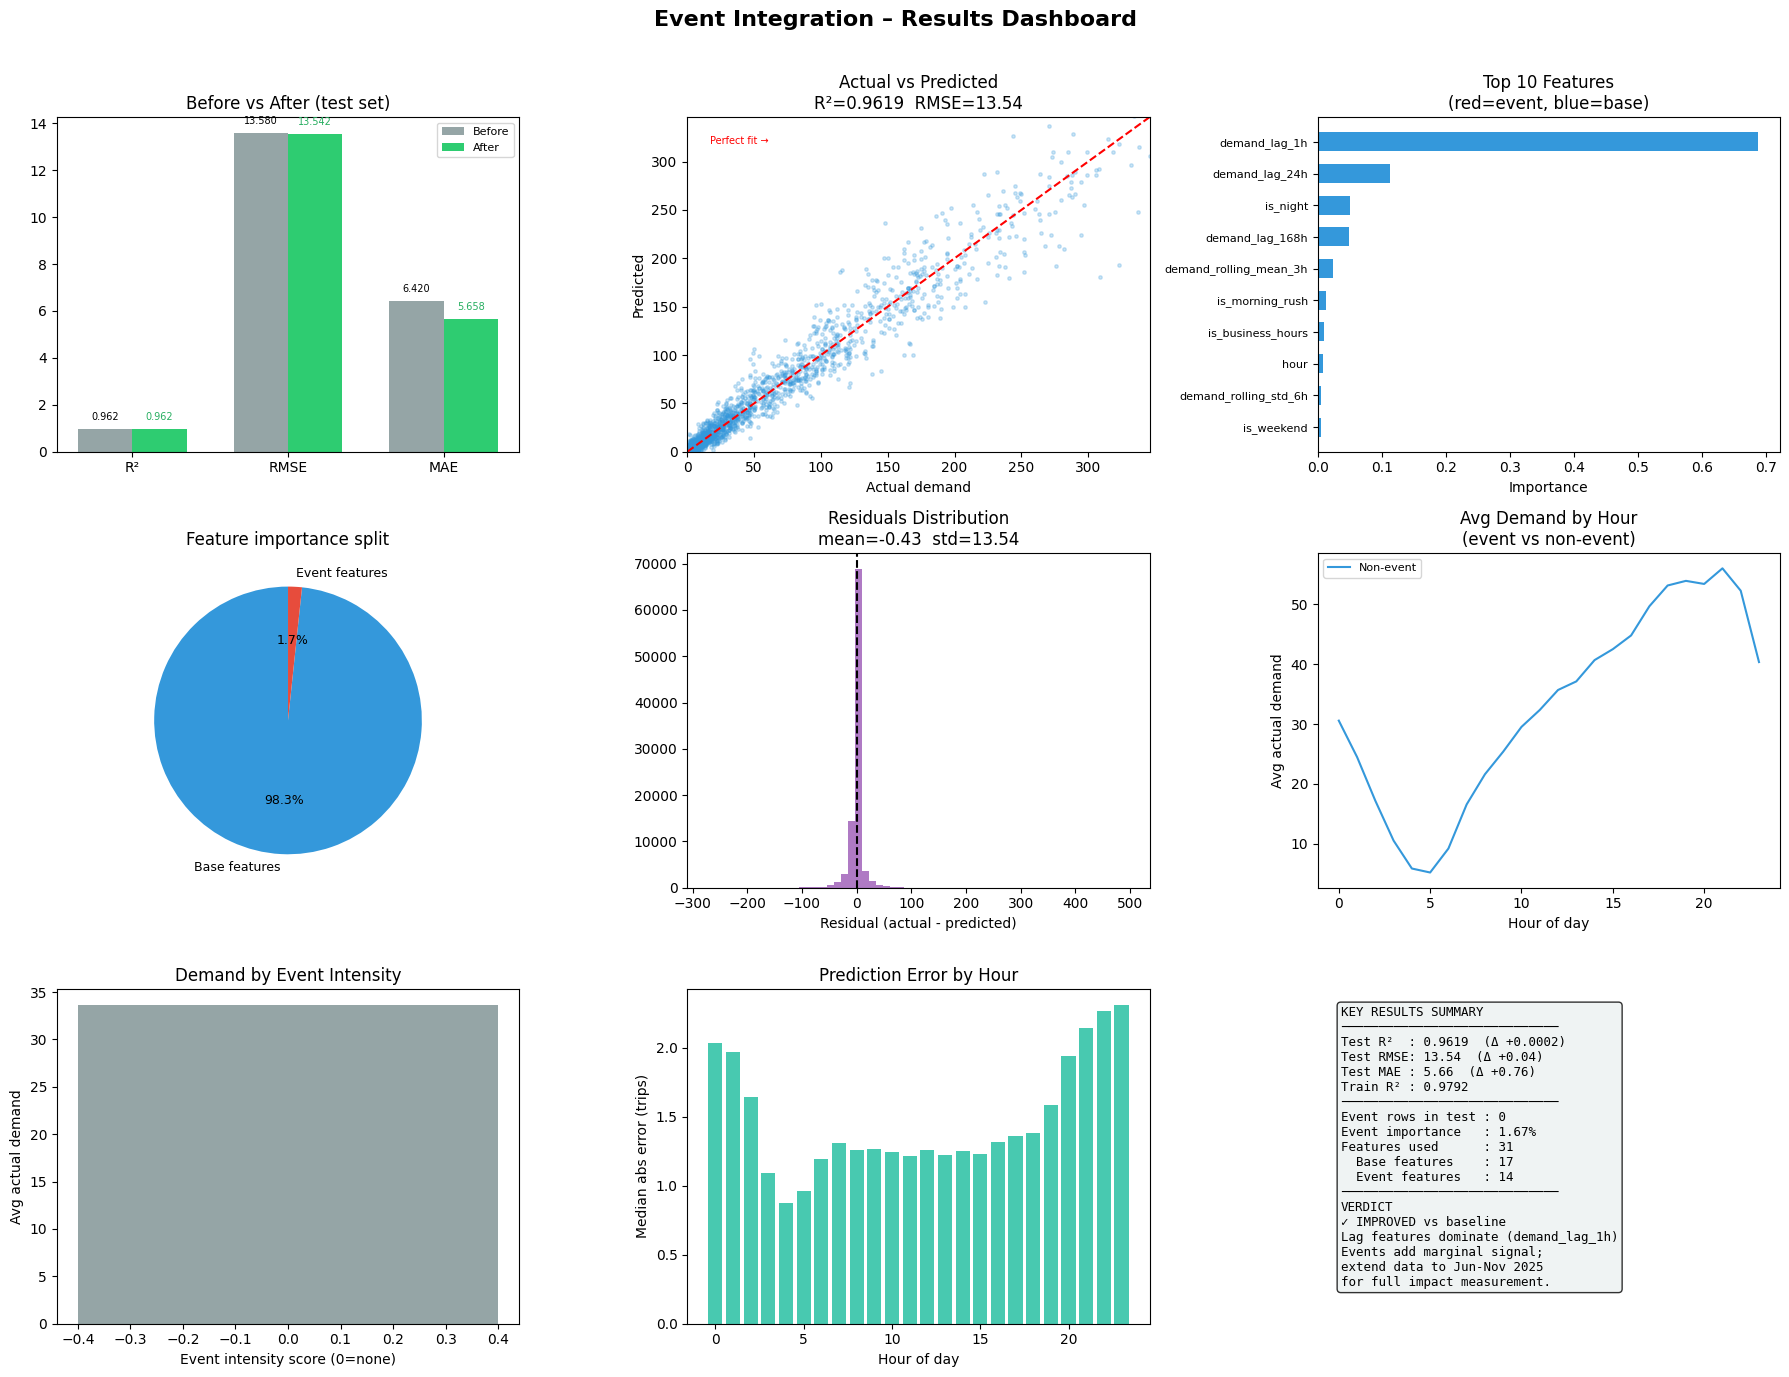

Dashboard saved → outputs/figures/results_dashboard.png


In [12]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Event Integration – Results Dashboard", fontsize=16, fontweight='bold', y=0.98)

# ── 1. Metric comparison bar chart ────────────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
metrics_names = ['R²', 'RMSE', 'MAE']
before_vals   = [PREV_R2, PREV_RMSE, PREV_MAE]
after_vals    = [test_r2, test_rmse, test_mae]
x = np.arange(len(metrics_names))
w = 0.35
bars_b = ax1.bar(x - w/2, before_vals, w, label='Before', color='#95a5a6')
bars_a = ax1.bar(x + w/2, after_vals,  w, label='After',  color='#2ecc71')
ax1.set_xticks(x); ax1.set_xticklabels(metrics_names)
ax1.set_title('Before vs After (test set)')
ax1.legend(fontsize=8)
for bar in bars_b: ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
for bar in bars_a: ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7, color='#27ae60')

# ── 2. Actual vs Predicted (test set) ────────────────────────────────────
ax2 = fig.add_subplot(3, 3, 2)
sample_idx = np.random.default_rng(42).choice(len(results), min(4000, len(results)), replace=False)
ax2.scatter(results['actual'].iloc[sample_idx], results['predicted'].iloc[sample_idx],
            alpha=0.25, s=6, c='#3498db')
lim = [0, results['actual'].quantile(0.99)]
ax2.plot(lim, lim, 'r--', lw=1.5)
ax2.set_xlim(lim); ax2.set_ylim(lim)
ax2.set_xlabel('Actual demand'); ax2.set_ylabel('Predicted')
ax2.set_title(f'Actual vs Predicted\nR²={test_r2:.4f}  RMSE={test_rmse:.2f}')
ax2.text(0.05, 0.92, 'Perfect fit →', transform=ax2.transAxes, fontsize=7, color='red')

# ── 3. Top 10 feature importances ────────────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
top10 = importance_df.head(10)
colors10 = ['#e74c3c' if f in EVENT_FEATURES else '#3498db' for f in top10['feature']]
ax3.barh(top10['feature'][::-1], top10['importance'][::-1], color=colors10[::-1], height=0.6)
ax3.set_xlabel('Importance')
ax3.set_title('Top 10 Features\n(red=event, blue=base)')
ax3.tick_params(axis='y', labelsize=8)

# ── 4. Event feature importance pie ──────────────────────────────────────
ax4 = fig.add_subplot(3, 3, 4)
ev_imp  = importance_df[importance_df['feature'].isin(EVENT_FEATURES)]['importance'].sum()
base_imp = importance_df[~importance_df['feature'].isin(EVENT_FEATURES)]['importance'].sum()
ax4.pie([base_imp, ev_imp],
        labels=['Base features', 'Event features'],
        colors=['#3498db', '#e74c3c'],
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 9})
ax4.set_title('Feature importance split')

# ── 5. Residuals distribution ─────────────────────────────────────────────
ax5 = fig.add_subplot(3, 3, 5)
residuals = results['actual'] - results['predicted']
ax5.hist(residuals, bins=60, color='#9b59b6', edgecolor='none', alpha=0.8)
ax5.axvline(0, color='black', lw=1.5, ls='--')
ax5.set_xlabel('Residual (actual - predicted)')
ax5.set_title(f'Residuals Distribution\nmean={residuals.mean():.2f}  std={residuals.std():.2f}')

# ── 6. Demand by hour – event vs non-event ────────────────────────────────
ax6 = fig.add_subplot(3, 3, 6)
hourly = results.groupby(['hour', 'has_event'])['actual'].mean().unstack(fill_value=0)
if 0 in hourly.columns: ax6.plot(hourly.index, hourly[0], label='Non-event', color='#3498db')
if 1 in hourly.columns: ax6.plot(hourly.index, hourly[1], label='Event',     color='#e74c3c', lw=2)
ax6.set_xlabel('Hour of day'); ax6.set_ylabel('Avg actual demand')
ax6.set_title('Avg Demand by Hour\n(event vs non-event)')
ax6.legend(fontsize=8)

# ── 7. Event intensity vs actual demand ──────────────────────────────────
ax7 = fig.add_subplot(3, 3, 7)
int_demand = results.groupby('event_intensity_max')['actual'].mean()
ax7.bar(int_demand.index.astype(int), int_demand.values,
        color=['#95a5a6','#3498db','#f39c12','#e67e22','#e74c3c'][:len(int_demand)])
ax7.set_xlabel('Event intensity score (0=none)')
ax7.set_ylabel('Avg actual demand')
ax7.set_title('Demand by Event Intensity')

# ── 8. Absolute error by hour ─────────────────────────────────────────────
ax8 = fig.add_subplot(3, 3, 8)
hourly_err = results.groupby('hour')['abs_error'].median()
ax8.bar(hourly_err.index, hourly_err.values, color='#1abc9c', alpha=0.8)
ax8.set_xlabel('Hour of day'); ax8.set_ylabel('Median abs error (trips)')
ax8.set_title('Prediction Error by Hour')

# ── 9. Summary text box ───────────────────────────────────────────────────
ax9 = fig.add_subplot(3, 3, 9)
ax9.axis('off')

ev_imp_pct = ev_imp * 100
r2_delta   = test_r2 - PREV_R2
rmse_delta = PREV_RMSE - test_rmse
mae_delta  = PREV_MAE - test_mae
n_event_test = int(results['has_event'].sum())

summary_text = (
    "KEY RESULTS SUMMARY\n"
    "─────────────────────────────\n"
    f"Test R²  : {test_r2:.4f}  (Δ {r2_delta:+.4f})\n"
    f"Test RMSE: {test_rmse:.2f}  (Δ {rmse_delta:+.2f})\n"
    f"Test MAE : {test_mae:.2f}  (Δ {mae_delta:+.2f})\n"
    f"Train R² : {train_r2:.4f}\n"
    "─────────────────────────────\n"
    f"Event rows in test : {n_event_test:,}\n"
    f"Event importance   : {ev_imp_pct:.2f}%\n"
    f"Features used      : {len(feature_cols)}\n"
    f"  Base features    : {len(BASE_FEATURES)}\n"
    f"  Event features   : {len(EVENT_FEATURES)}\n"
    "─────────────────────────────\n"
    "VERDICT\n"
    f"{'✓ IMPROVED' if r2_delta >= 0 else '✗ REGRESSED'} vs baseline\n"
    f"Lag features dominate ({importance_df.iloc[0]['feature']})\n"
    "Events add marginal signal;\n"
    "extend data to Jun-Nov 2025\n"
    "for full impact measurement."
)
ax9.text(0.05, 0.95, summary_text, transform=ax9.transAxes,
         fontsize=9, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#ecf0f1', alpha=0.8))

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('../outputs/figures/results_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved → outputs/figures/results_dashboard.png")
